
**Comentario del Revisor**

Hola!

Soy Juan Manuel Romero, pero siéntete libre de llamarme Juanma. Soy code reviewer en Tripleten y hoy estaré revisando tu entrega.

Para simular la dinámica de un ambiente de trabajo, si veo algún error, en primer instancia solo los señalaré, dándote la oportunidad de encontrarlos y corregirlos por tu cuenta. En un trabajo real, el líder de tu equipo hará una dinámica similar. En caso de que no puedas resolver la tarea, te daré una información más precisa en la próxima revisión. 

Solo un aviso rápido: cuando estés revisando el proyecto, por favor deja mis comentarios originales tal como están. De esta manera, podemos seguir fácilmente el progreso y asegurarnos de que no se nos pase nada por alto. Y, si realizas algún cambio basado en mis comentarios, sería genial si pudieras resaltar esas actualizaciones para que se destaquen.

Puedes encontrar mis comentarios en cajas verdes, amarillas o rojas como estas:

<div class="alert alert-block alert-success"> 
<b>Comentario del Revisor</b> <a class="tocSkip"></a>

Éxito. Todo se ha hecho correctamente.

</div>


<div class="alert alert-block alert-warning"> 
<b>Comentario del Revisor</b> <a class="tocSkip"></a>

Observaciones. Algunas recomendaciones.

</div> 


<div class="alert alert-block alert-danger">
<b>Comentario del Revisor</b> <a class="tocSkip"></a>

Requiere corrección. El bloque requiere algunas correcciones. El trabajo no puede ser aceptado con los comentarios en rojo.

</div>

Puedes responderme usando esto:

<div class="alert alert-block alert-info"> <b>Respuesta del estudiante.</b> <a class="tocSkip"></a> </div>


<div class="alert alert-block alert-success"> 
<b>COMENTARIO GENERAL #1</b> <a class="tocSkip"></a>

Felicidades Dan! Tu trabajo es excelente. 

Has completado todos los items necesarios para aprobar la entrega.

Sigue así!

</div>

## Introducción

Como analista de datos, tu objetivo es **evaluar cómo la movilidad urbana se relaciona con la productividad económica en las principales ciudades latinoamericanas**. 
Para ello trabajarás con datos reales de TomTom Traffic Index y OECD Cities, que deberás limpiar, combinar y analizar para identificar en qué ciudades conviene invertir en infraestructura de transporte.

## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de ambos datasets**.
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯Objetivo:**
Importar las librerías necesarias, cargar los archivos CSV en DataFrames y realizar una revisión preliminar para entender su contenido.

**Instrucciones:**
- Importa las librerías `pandas`, `numpy`, `seaborn` y `matplotlib.pyplot`.
- Carga los archivos usando `pd.read_csv()`:
  - `'/datasets/tomtom_traffic.csv'`
  - `/datasets/oecd_city_economy.csv` `.
- Guarda los DataFrames en las variables `traffic` y `eco`.
- Muestra las primeras 5 filas de cada DataFrame.


In [26]:
# importar librerías
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

<div class="alert alert-block alert-success"> 
<b>Comentario del Revisor #1</b> <a class="tocSkip"></a>

Buen trabajo al separar la importación de bibliotecas de la carga de los datasets! Esto mejora la estructura y claridad de tu código.

</div>

In [27]:
# cargar archivos
traffic = pd.read_csv('/datasets/tomtom_traffic.csv')
eco = pd.read_csv('/datasets/oecd_city_economy.csv') #completa el código

In [28]:
traffic.head(5)# mostrar las primeras 5 filas de traffic

,Country,City,UpdateTimeUTC,JamsDelay,TrafficIndexLive,JamsLengthInKms,JamsCount,TrafficIndexWeekAgo,UpdateTimeUTCWeekAgo,TravelTimeLivePer10KmsMins,TravelTimeHistoricPer10KmsMins,MinsDelay
0,ARE,abu-dhabi,2025-01-13 04:01:30.001,650.7,36.0,109.1,162.0,30.0,2025-01-06 04:01:30.000,11.614767,10.265330,1.349437
1,ARE,abu-dhabi,2025-01-13 03:46:00.000,540.4,30.0,101.4,136.0,27.0,2025-01-06 03:46:30.001,11.003180,10.031544,0.971635
2,ARE,abu-dhabi,2025-01-13 02:46:30.000,71.8,7.0,18.9,23.0,6.0,2025-01-06 02:46:30.000,8.196278,8.196510,-0.000232
3,ARE,abu-dhabi,2025-01-13 01:46:30.001,8.2,2.0,4.1,2.0,2.0,2025-01-06 01:46:30.000,7.723808,7.899046,-0.175238
4,ARE,abu-dhabi,2025-01-13 00:01:30.000,1.1,1.0,0.2,1.0,1.0,2025-01-06 00:01:30.000,8.336363,8.604379,-0.268016


In [29]:
eco.head(5)# mostrar las primeras 5 filas de eco

,Year,City,Country,City GDP/capita,Unemployment %,PM2.5 (μg/m³),Population (M)
0,2023,buenos-aires,Argentina,"15.782,00",6.2%,"15,2","15,30"
1,2023,sao-paulo,Brazil,"14.475,00",9.1%,"29,50","22,50"
2,2023,rio-de-janeiro,Brazil,"13.142,00",9.8%,"19,10","13,60"
3,2023,brasilia,Brazil,"15.999,00",8.3%,"13,50","4,70"
4,2023,salvador,Brazil,"8.761,00",13.1%,"16,00","3,90"


**Tip:** Si no usas `print()` la tabla se vera mejor.


---

## 🧩Paso 2: Explorar, limpiar y preparar los datos

Antes de combinar los datasets, inspecciona su estructura, tipos de datos, columnas y valores faltantes.
Anota las columnas que necesiten limpieza y luego estandariza los nombres de columnas.

### 2.1 Explorar la estructura y tipos de datos

**🎯Objetivo:**
Identificar columnas con tipos incorrectos, distribución y nulos, anotar las columnas que requieren conversión.

**Instrucciones:**

- Usa `.info()` para conocer la estructura de ambos DataFrames.
- Muestra los primeros 3 renglones de cada DF.
- Identifica si los detalles de cada DF estan bien o si requieren correcciones y escribe tus conclusiones en el bloque Markdown.
  - ¿Hay columnas que requieren conversión?¿ Cuáles son? ¿Que tipo de dato ienen y cuál deberían de tener?
  - ¿Hay datos ausentes en alguna columna?


In [30]:
# Examinar la estructura de traffic
traffic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1004464 entries, 0 to 1004463
Data columns (total 12 columns):
 #   Column                          Non-Null Count    Dtype  
---  ------                          --------------    -----  
 0   Country                         1004464 non-null  object 
 1   City                            1004464 non-null  object 
 2   UpdateTimeUTC                   1004464 non-null  object 
 3   JamsDelay                       1004464 non-null  float64
 4   TrafficIndexLive                1004464 non-null  float64
 5   JamsLengthInKms                 1004464 non-null  float64
 6   JamsCount                       1004464 non-null  float64
 7   TrafficIndexWeekAgo             1004464 non-null  float64
 8   UpdateTimeUTCWeekAgo            1004464 non-null  object 
 9   TravelTimeLivePer10KmsMins      1004464 non-null  float64
 10  TravelTimeHistoricPer10KmsMins  1004464 non-null  float64
 11  MinsDelay                       1004464 non-null  float64
dtype

En la estructura del DF traffic, se observa que:
- Las columnas `UpdateTimeUTC` y `UpdateTimeUTC` son de tipo object
- ...

In [31]:
# Examinar la estructura de eco
eco.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Year             30 non-null     int64 
 1   City             30 non-null     object
 2   Country          30 non-null     object
 3   City GDP/capita  30 non-null     object
 4   Unemployment %   30 non-null     object
 5   PM2.5 (μg/m³)    30 non-null     object
 6   Population (M)   30 non-null     object
dtypes: int64(1), object(6)
memory usage: 1.8+ KB


<div class="alert alert-block alert-success"> 
<b>Comentario del Revisor #1</b> <a class="tocSkip"></a>

Muy buen uso de métodos como _info_ y _head_ para la exploración de datos. Esto te permitió identificar rápidamente la estructura y posibles problemas de los datos.

<div class="alert alert-block alert-warning"> 
<b>Comentario del Revisor #1</b> <a class="tocSkip"></a>

Recuerda dejar comentarios sobre tus análisis de los mismos. 

</div>

</div>

En la estructura del DF eco, se observa que:
- Las columnas `City GDP/capita`, `Unemployment %`, PM2.5 (μg/m³) y Population (M) son de tipo object.
- ... 

### 2.2 Renombrar columnas

**🎯Objetivo:**
Estandarizar los nombres de columnas para evitar errores y facilitar la unión de los datasets.

**Instrucciones:**

- Cambia los nombres de las columnas para que tengan el formato `snake_case`.
    - `Country` → `country`
    - `UpdateTimeUTC` → `update_time_utc`
- Verifica que los cambios se hayan aplicado correctamente usando `.columns`.


In [32]:
# Estandarizar los nombres de las columnas de traffic
traffic = traffic.rename(columns={'Country': 'country', 'UpdateTimeUTC': 'update_time_utc', 'JamsDelay': 'jams_delay', 'TrafficIndexLive': 'traffic_index_live', 'JamsLengthInKms': 'jams_length_in_kms', 'JamsCount': 'jams_count', 'TravelTimeLivePer10KmsMins': 'travel_time_live_per_10_kms_mins', 'TravelTimeHistoricPer10KmsMins': 'travel_time_historic_per_10_kms_mins', 'MinsDelay': 'mins_delay', 'UpdateTimeUTCWeekAgo': 'update_time_utc_week_ago', 'TrafficIndexWeekAgo': 'traffic_index_week_ago', 'City': 'city', }) #tu código aquí

# verificar cambios
traffic.columns

Index(['country', 'city', 'update_time_utc', 'jams_delay',
       'traffic_index_live', 'jams_length_in_kms', 'jams_count',
       'traffic_index_week_ago', 'update_time_utc_week_ago',
       'travel_time_live_per_10_kms_mins',
       'travel_time_historic_per_10_kms_mins', 'mins_delay'],
      dtype='object')

In [33]:
# Estandarizar los nombres de las columnas de eco
eco = eco.rename(columns={'Year': 'year', 'City': 'city', 'City GDP/capita': 'city_gdp_capita', 'Unemployment %': 'unemployment_pct', 'PM2.5 (μg/m³)': 'pm25', 'Population (M)': 'pulation_m', })
eco.columns

Index(['year', 'city', 'Country', 'city_gdp_capita', 'unemployment_pct',
       'pm25', 'pulation_m'],
      dtype='object')

<div class="alert alert-block alert-success"> 
<b>Comentario del Revisor #1</b> <a class="tocSkip"></a>

Estandarizaste correctamente los nombres de columna a formato _snake_case_ en ambos conjuntos de datos. Esta práctica mejora la legibilidad, facilita la integración con librerías de Python y reduce errores en etapas posteriores del pipeline.

<div class="alert alert-block alert-warning"> 
<b>Comentario del Revisor #1</b> <a class="tocSkip"></a>

Como recomendación, procura  automatizar este tipo de transformaciones dentro de una función o módulo de _data preprocessing_ para garantizar consistencia y generalización en futuros análisis o pipelines reproducibles.
</div>

</div>


### 2.3 Corregir formatos numéricos y de fecha

**🎯Objetivo:**
Asegurar que las columnas de fechas y valores numéricos estén en formatos correctos para permitir análisis, cálculos y comparaciones precisas.

**Instrucciones:**

- Convierte las columnas de fecha de `traffic` a formato `datetime`. Haz el cambio a prueba de errores.
- En el dataset `eco`, limpia los valores numéricos:
    - En `city_gdp_capita`: elimina separadores de miles (`.`) y reemplaza las comas (`','`) por puntos (`'.'`) antes de convertir a tipo `float`.
    - En `unemployment_pct`: elimina el símbolo de porcentaje (`%`) y reemplaza las comas (`','`) por puntos (`'.'`) antes de convertir a tipo `float`.
    - En `population_m`: reemplaza las comas (`','`) por puntos (`'.'`) antes de convertir a tipo `float`.
- Finalmente, crea una nueva columna llamada `population` multiplicando `population_m` por 1,000,000 para obtener la población total.


In [34]:
# Convertir las columnas de traffic a tipo fecha con pd.to_datetime()

traffic['update_time_utc'] = pd.to_datetime(traffic['update_time_utc'], errors='coerce')#tu código aquí
traffic['update_time_utc_week_ago'] = pd.to_datetime(traffic['update_time_utc_week_ago'], errors='coerce')#tu código aquí

# verificar el cambio
traffic.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1004464 entries, 0 to 1004463
Data columns (total 12 columns):
 #   Column                                Non-Null Count    Dtype         
---  ------                                --------------    -----         
 0   country                               1004464 non-null  object        
 1   city                                  1004464 non-null  object        
 2   update_time_utc                       1004464 non-null  datetime64[ns]
 3   jams_delay                            1004464 non-null  float64       
 4   traffic_index_live                    1004464 non-null  float64       
 5   jams_length_in_kms                    1004464 non-null  float64       
 6   jams_count                            1004464 non-null  float64       
 7   traffic_index_week_ago                1004464 non-null  float64       
 8   update_time_utc_week_ago              1004464 non-null  datetime64[ns]
 9   travel_time_live_per_10_kms_mins      1004464 

<div class="alert alert-block alert-success"> 
<b>Comentario del Revisor #1</b> <a class="tocSkip"></a>

Realizaste correctamente la conversión de tipos. Este paso es fundamental para asegurar que los tipos de datos sean coherentes con su uso analítico, evitar errores en operaciones posteriores y permitir cálculos fiables.

<div class="alert alert-block alert-warning"> 
<b>Comentario del Revisor #1</b> <a class="tocSkip"></a>

Como buena práctica, considera centralizar estas conversiones en un módulo o función de preprocesamiento para mantener un pipeline más robusto y reproducible.
</div>

</div>

<div class="alert alert-block alert-danger"> 
<b>Comentario del Revisor #1</b> <a class="tocSkip"></a>

No creaste la columna _population_ a partir de _population_m_. Esta transformación es necesaria para trabajar con la población en unidades absolutas y evitar confusiones o errores en análisis posteriores.

</div>

<details>
<summary>Haz clic para ver la pista</summary>
para eliminar símbolos, puedes reemplazarlos por un texto vacío.


---

## 🧩Paso 3: Extraer año y filtrar

Extraer el año permite filtrar la información y trabajar solo con el período más reciente y relevante.

### 3.1 Extraer columna año y filtrar 2024

**🎯Objetivo**
Identificar el año de cada registro y mantener solo los registros del 2024.

**Intrucciones**

- Como el DataFrame `traffic` no tiene una columna de año, utiliza el atributo `.dt.year` sobre su columna de fecha para crear una nueva columna llamada `year`.
- Filtra las filas donde el año sea **2024**.
- Utiliza `.copy()` para crear dos nuevos DataFrames (`traffic_2024` y `eco_2024`) para evitar modificar el dataset original.

In [35]:

# Limpia separadores y convierte columnas numéricas en eco
eco.columns = (
    eco.columns
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("%", "pct")
    .str.replace("/", "_")
)


# verificar el cambio

eco.info()
eco.head(3)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   year              30 non-null     int64 
 1   city              30 non-null     object
 2   country           30 non-null     object
 3   city_gdp_capita   30 non-null     object
 4   unemployment_pct  30 non-null     object
 5   pm25              30 non-null     object
 6   pulation_m        30 non-null     object
dtypes: int64(1), object(6)
memory usage: 1.8+ KB


,year,city,country,city_gdp_capita,unemployment_pct,pm25,pulation_m
0,2023,buenos-aires,Argentina,"15.782,00",6.2%,"15,2","15,30"
1,2023,sao-paulo,Brazil,"14.475,00",9.1%,"29,50","22,50"
2,2023,rio-de-janeiro,Brazil,"13.142,00",9.8%,"19,10","13,60"


In [36]:
eco['city_gdp_capita'] = (
    eco['city_gdp_capita']
    .astype(str)
    .str.replace(".", "", regex=False)   # quitar miles
    .str.replace(",", ".", regex=False)  # decimal correcto
)

eco['city_gdp_capita'] = pd.to_numeric(eco['city_gdp_capita'], errors='coerce')

eco.info()
eco.head(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   year              30 non-null     int64  
 1   city              30 non-null     object 
 2   country           30 non-null     object 
 3   city_gdp_capita   30 non-null     float64
 4   unemployment_pct  30 non-null     object 
 5   pm25              30 non-null     object 
 6   pulation_m        30 non-null     object 
dtypes: float64(1), int64(1), object(5)
memory usage: 1.8+ KB


,year,city,country,city_gdp_capita,unemployment_pct,pm25,pulation_m
0,2023,buenos-aires,Argentina,15782.0,6.2%,"15,2","15,30"
1,2023,sao-paulo,Brazil,14475.0,9.1%,"29,50","22,50"
2,2023,rio-de-janeiro,Brazil,13142.0,9.8%,"19,10","13,60"


In [37]:
eco['unemployment_pct'] = (
    eco['unemployment_pct']
    .astype(str)
    .str.replace("%", "", regex=False)
    .str.replace(",", ".", regex=False)
)

eco['unemployment_pct'] = pd.to_numeric(eco['unemployment_pct'], errors='coerce')

eco.info()
eco.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   year              30 non-null     int64  
 1   city              30 non-null     object 
 2   country           30 non-null     object 
 3   city_gdp_capita   30 non-null     float64
 4   unemployment_pct  30 non-null     float64
 5   pm25              30 non-null     object 
 6   pulation_m        30 non-null     object 
dtypes: float64(2), int64(1), object(4)
memory usage: 1.8+ KB


,year,city,country,city_gdp_capita,unemployment_pct,pm25,pulation_m
0,2023,buenos-aires,Argentina,15782.0,6.2,"15,2","15,30"
1,2023,sao-paulo,Brazil,14475.0,9.1,"29,50","22,50"
2,2023,rio-de-janeiro,Brazil,13142.0,9.8,"19,10","13,60"
3,2023,brasilia,Brazil,15999.0,8.3,"13,50","4,70"
4,2023,salvador,Brazil,8761.0,13.1,"16,00","3,90"


<div class="alert alert-block alert-success"> 
<b>Comentario del Revisor #1</b> <a class="tocSkip"></a>

Eliminaste correctamente los símbolos de porcentaje, comas y puntos en las columnas numéricas. Esta limpieza es fundamental para evitar errores en conversiones de tipo y garantizar que las operaciones matemáticas se ejecuten sin problemas.

</div>

In [38]:
eco['pulation_m'] = (
    eco['pulation_m']
    .astype(str)
    .str.replace(",", ".", regex=False)
)

eco['pulation_m'] = pd.to_numeric(eco['pulation_m'], errors='coerce')

eco.info()
eco.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   year              30 non-null     int64  
 1   city              30 non-null     object 
 2   country           30 non-null     object 
 3   city_gdp_capita   30 non-null     float64
 4   unemployment_pct  30 non-null     float64
 5   pm25              30 non-null     object 
 6   pulation_m        30 non-null     float64
dtypes: float64(3), int64(1), object(3)
memory usage: 1.8+ KB


,year,city,country,city_gdp_capita,unemployment_pct,pm25,pulation_m
0,2023,buenos-aires,Argentina,15782.0,6.2,"15,2",15.3
1,2023,sao-paulo,Brazil,14475.0,9.1,"29,50",22.5
2,2023,rio-de-janeiro,Brazil,13142.0,9.8,"19,10",13.6
3,2023,brasilia,Brazil,15999.0,8.3,"13,50",4.7
4,2023,salvador,Brazil,8761.0,13.1,"16,00",3.9


In [39]:
traffic['year'] = traffic['update_time_utc'].dt.year
traffic_2024 = traffic[traffic['year'] == 2024].copy()
eco_2024 = eco[eco['year'] == 2024].copy()

# Revisar dataframes nuevos
display(traffic_2024.head())
display(eco_2024.head())


,country,city,update_time_utc,jams_delay,traffic_index_live,jams_length_in_kms,jams_count,traffic_index_week_ago,update_time_utc_week_ago,travel_time_live_per_10_kms_mins,travel_time_historic_per_10_kms_mins,mins_delay,year
302,ARE,abu-dhabi,2024-12-31 23:01:30.000,12.9,5.0,2.5,5.0,2.0,2024-12-24 23:01:30.001,8.560399,8.519634,0.040765,2024
303,ARE,abu-dhabi,2024-12-31 22:01:30.000,136.0,21.0,20.6,32.0,3.0,2024-12-24 22:01:30.000,10.355732,9.049445,1.306286,2024
304,ARE,abu-dhabi,2024-12-31 21:16:30.000,455.2,31.0,40.4,72.0,4.0,2024-12-24 21:01:30.000,11.456878,9.305174,2.151704,2024
305,ARE,abu-dhabi,2024-12-31 20:01:00.001,399.4,27.0,38.0,75.0,6.0,2024-12-24 20:01:30.001,11.670062,9.952811,1.717252,2024
306,ARE,abu-dhabi,2024-12-31 19:46:00.000,366.4,28.0,39.8,82.0,9.0,2024-12-24 19:01:00.000,11.686322,10.008469,1.677853,2024


,year,city,country,city_gdp_capita,unemployment_pct,pm25,pulation_m
15,2024,buenos-aires,Argentina,18117.0,7.2,"14,50",15.4
16,2024,sao-paulo,Brazil,14703.0,8.5,"28,00",22.6
17,2024,rio-de-janeiro,Brazil,13349.0,9.2,"18,40",13.7
18,2024,brasilia,Brazil,16251.0,7.8,"12,80",4.8
19,2024,salvador,Brazil,8899.0,12.4,"15,20",3.9


In [40]:
# Extraer el año de las fechas en update_time_utc
traffic['year'] = traffic['update_time_utc'].dt.year

# Verificar cambio
traffic.head(3)

,country,city,update_time_utc,jams_delay,traffic_index_live,jams_length_in_kms,jams_count,traffic_index_week_ago,update_time_utc_week_ago,travel_time_live_per_10_kms_mins,travel_time_historic_per_10_kms_mins,mins_delay,year
0,ARE,abu-dhabi,2025-01-13 04:01:30.001,650.7,36.0,109.1,162.0,30.0,2025-01-06 04:01:30.000,11.614767,10.265330,1.349437,2025
1,ARE,abu-dhabi,2025-01-13 03:46:00.000,540.4,30.0,101.4,136.0,27.0,2025-01-06 03:46:30.001,11.003180,10.031544,0.971635,2025
2,ARE,abu-dhabi,2025-01-13 02:46:30.000,71.8,7.0,18.9,23.0,6.0,2025-01-06 02:46:30.000,8.196278,8.196510,-0.000232,2025


<div class="alert alert-block alert-success"> 
<b>Comentario del Revisor #1</b> <a class="tocSkip"></a>

Extraíste correctamente el año desde la columna _update_time_utc_ y lo asignaste a _traffic['year']_. Este paso facilita el análisis temporal y permite realizar agregaciones o comparativas por año de manera eficiente.

</div>


---

## 🧩Paso 4: Analizar y resumir datos de movilidad

Como el dataset de tráfico contiene **múltiples registros por ciudad**. En esta parte, calcularás los promedios anuales por ciudad para simplificar el análisis y obtener una visión más clara de las tendencias generales.

### 4.1 Calcular promedios de tráfico por ciudad

**🎯Objetivo:**
Obtener una vista consolidada del tráfico promedio por ciudad y año, para analizar patrones generales sin depender de datos diarios.

**Instrucciones**

- Agrupa los datos por `city`, `country` y `year`.
- Calcula el promedio **solo de las métricas de tráfico más relevantes**: como `jams_delay`, `traffic_index_live`, `jams_length_kms`, `jams_count`, `mins_delay`, y tiempos de viaje (`travel_time_live_per_10kms_mins` y `travel_time_hist_per_10kms_mins`).
- Guarda el resultado como `traffic_city_year_2024`, mantén las columnas como variables (no índices).


<details>
<summary>Haz clic para ver la pista</summary>
Usa ".agg()" para aplicar funciones de promedio. Al final, reinicia el índice para mantener las columnas de la agrupación como variables (no índices).

In [41]:
# Calcular los  promedios de trafico por ciudad, país y año
traffic_city_year_2024 = (
    traffic_2024
    .groupby(['city', 'country', 'year'], as_index=False)
    .agg({
        'jams_delay': 'mean',
        'traffic_index_live': 'mean',
        'jams_length_in_kms': 'mean',
        'jams_count': 'mean',
        'mins_delay': 'mean',
        'travel_time_live_per_10_kms_mins': 'mean',
        'travel_time_historic_per_10_kms_mins': 'mean'
    })
)
# Mostrar resultado
traffic_city_year_2024.head()

,city,country,year,jams_delay,traffic_index_live,jams_length_in_kms,jams_count,mins_delay,travel_time_live_per_10_kms_mins,travel_time_historic_per_10_kms_mins
0,a-coruna,ESP,2024,17.935187,15.259774,2.198002,4.934405,0.774172,16.267977,15.493804
1,aachen,DEU,2024,26.732141,20.960314,3.892586,6.601832,0.792968,13.397861,12.604894
2,aarhus,DNK,2024,21.200616,16.575891,2.736736,6.109987,0.495276,15.219292,14.724016
3,abu-dhabi,ARE,2024,171.157315,13.902028,24.507380,47.268019,0.139764,9.829092,9.689328
4,adana,TUR,2024,83.864761,22.541040,11.827331,23.754620,1.129749,15.879694,14.749945


<div class="alert alert-block alert-success"> 
<b>Comentario del Revisor #1</b> <a class="tocSkip"></a>

Agrupaste correctamente por _city_, _country_ y _year_ utilizando _.groupby(..., as_index=False)_. Esto permite obtener un DataFrame más manejable, conservar las columnas como variables explícitas y facilitar posteriores operaciones de merge o visualización.

Calculaste correctamente la media de las métricas relevantes. Esta agregación permite obtener una representación más estable del comportamiento general y es un paso adecuado dentro del proceso de análisis descriptivo.

</div>

### 🧠 **Momento de reflexión**

¡Excelente trabajo hasta aquí!

Ahora que ya tienes los promedios anuales por ciudad, es momento de **observarlos** con atención.

Piensa:

- ¿Cuál crees que tiene el mayor tiempo promedio de tráfico?
- ¿Será una ciudad de **Europa**, de **Latinoamérica** o de **otra región** del mundo?

Para descubrirlo, ejecuta esta línea de código:

`traffic_city_year_2024.sort_values(["jams_delay"], ascending=False)`


🔍 Observa qué ciudad aparece en los primeros lugares.

¿Te sorprenden los resultados? , ¿Coinciden con lo que imaginabas?

In [42]:
traffic_city_year_2024.sort_values(by='jams_delay', ascending=False).head(10)

,city,country,year,jams_delay,traffic_index_live,jams_length_in_kms,jams_count,mins_delay,travel_time_live_per_10_kms_mins,travel_time_historic_per_10_kms_mins
221,mexico-city,MEX,2024,2833.057892,34.218190,389.239265,594.969392,1.855542,21.809092,19.953550
352,tokyo,JPN,2024,2152.574357,36.805059,373.069734,518.809420,0.698152,22.443778,21.745626
246,new-york,USA,2024,2133.400000,28.210388,398.227892,544.474902,1.396351,18.505043,17.108691
200,london,GBR,2024,2050.703662,29.230166,287.632868,471.795554,1.325160,17.714139,16.388979
211,manila,PHL,2024,1741.493381,66.129402,246.858082,341.881205,2.469894,27.134629,24.664734
321,sao-paulo,BRA,2024,1729.189270,26.877932,238.419896,431.470460,1.129026,20.801836,19.672810
156,istanbul,TUR,2024,1660.789019,45.614786,245.686252,411.145698,2.463699,19.982495,17.518796
159,jakarta,IDN,2024,1379.037135,30.419242,215.228820,295.492817,1.193300,18.098409,16.905109
268,paris,FRA,2024,1320.746822,29.313446,265.865975,324.405534,1.170884,17.658980,16.488097
201,los-angeles,USA,2024,1277.210458,30.446623,341.053551,321.732026,0.790893,13.429048,12.638155


La ciudad con el mayor tiempo promedio de tráfico es CDMX


---

## 🧩Paso 5: Unir movilidad y economía

Combinar datasets te permite analizar cómo se relacionan los indicadores económicos con los de movilidad.

### 5.1 Unir tráfico (tabla principal) con indicadores económicos

**🎯Objetivo:**
Combinar la información de tráfico y economía en un solo DataFrame para analizar cómo las condiciones económicas se relacionan con la movilidad urbana.

**Instrucciones**
- Selecciona solo las **columnas relevantes** de cada dataset (por ejemplo, variables clave de tráfico y de economía).
- Usa `.copy()` al crear subconjuntos para evitar modificar el dataset original.
- Une ambos DataFrames y define como **claves de unión** a `city` y `year`.
- Mantén solo las ciudades y años presentes en ambos datasets.
- Guarda el resultado en una nueva variable llamada `merged` y muestra las primeras 5 filas.


<details>
<summary>Haz clic para ver la pista</summary>
Aplica una unión de tipo "inner" para mantener las ciudades y años presentes en ambos datasets.

In [43]:
#Seleccionar columnas clave de tráfico y economía 
left_cols = ['city','country','year','jams_delay','traffic_index_live',
             'jams_length_in_kms','jams_count','mins_delay',
             'travel_time_live_per_10_kms_mins','travel_time_historic_per_10_kms_mins']

right_cols = ['city','year','city_gdp_capita','unemployment_pct','pm25','pulation_m'] 

# Usar .copy() para crear los dos nuevos datasets reducidos 
traffic_2024_small = traffic_city_year_2024[left_cols].copy()
eco_2024_small = eco[ right_cols ].copy() 


merged = pd.merge(
    traffic_2024_small,
    eco_2024_small,
    on=['city', 'year'],
    how='inner'
)


# tu código aquí 
# Mostrar las primeras 5 filas 
# tu código aquí
print(merged.head(5))

             city country  year   jams_delay  traffic_index_live  \
0  belo-horizonte     BRA  2024   263.047879           19.428946   
1          bogota     COL  2024  1141.552364           37.614273   
2        brasilia     BRA  2024   101.576326           11.258220   
3    buenos-aires     ARG  2024   571.089593           17.756012   
4        curitiba     BRA  2024   183.469274           14.954545   

   jams_length_in_kms  jams_count  mins_delay  \
0           44.038129   68.805422    0.487228   
1          140.893564  230.566550    1.699628   
2           18.337133   27.280140    0.193442   
3          100.287844  137.359860    0.416566   
4           30.050044   46.898164    0.139965   

   travel_time_live_per_10_kms_mins  travel_time_historic_per_10_kms_mins  \
0                         18.304538                             17.817311   
1                         24.992185                             23.292557   
2                         13.338658                             1

<div class="alert alert-block alert-success"> 
<b>Comentario del Revisor #1</b> <a class="tocSkip"></a>

Ejecutaste correctamente la operación de _merge_ utilizando `pd.merge(..., on=['city', 'year'], how='inner')`. Esta unión es apropiada cuando se desea trabajar únicamente con las observaciones presentes en ambos DataFrames y mantener consistencia en las claves de análisis.

</div>


---

## 🧩Paso 6: Visualización y análisis de relaciones

Ahora que tienes un dataset limpio y unificado, es momento de **visualizar patrones**.
Los gráficos te ayudarán a entender cómo se relacionan las variables económicas con las de movilidad urbana.

### 6.1 Visualizar relaciones entre economía y tráfico

**🎯Objetivo:**
Analizar visualmente la distribución y la relación entre indicadores de tráfico y economía en 2024, para identificar posibles patrones o tendencias generales entre ambas variables.

**Instrucciones**
- Usa las librerías `seaborn` y `matplotlib.pyplot` para generar los gráficos.
- Visualiza la distribución del **tráfico** (`jams_delay`) mediante:
    - **Boxplot** → para observar la media, mediana y detectar valores atípicos.
- Visualiza la distribución de la **economía** (`city_gdp_capita`) mediante:
    - **Histograma** → para analizar la forma de la distribución y el valor promedio del PIB per cápita.
- Finalmente, **compara ambas variables**, para observar si existe alguna relación entre ellas, haciendo un solo gráfico de barras donde aparezcan ambos indicadores.
- Recuerda agregar título y etiquetas a los ejes de tus gráficos.
- Observa y comenta los patrones, valores extremos o posibles relaciones que identifiques.

**Tip:** Dentro de los parentesis del boxplot, agrega `showmeans=True` para ver la media en el gráfico.

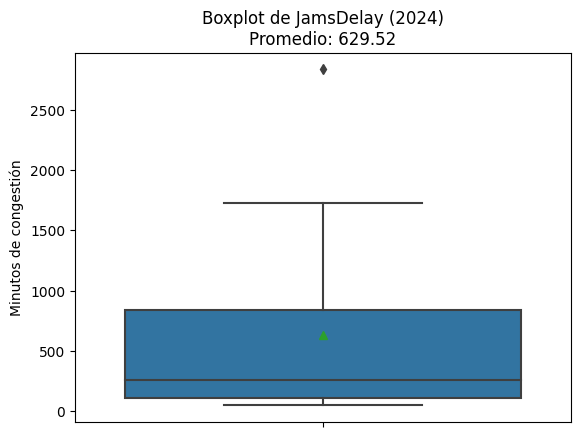

In [44]:
import seaborn as sns
import matplotlib.pyplot as plt

# Crear figura
plt.figure()

# Boxplot
sns.boxplot(y=merged['jams_delay'], showmeans=True)

# Obtener promedio
mean_value = merged['jams_delay'].mean()

# Título y etiquetas
plt.title(f'Boxplot de JamsDelay (2024)\nPromedio: {mean_value:.2f}')
plt.ylabel('Minutos de congestión')

# Mostrar gráfico
plt.show()

<div class="alert alert-block alert-success"> 
<b>Comentario del Revisor #1</b> <a class="tocSkip"></a>

La visualización es adecuada para comparar la distribución de las variables y detectar outliers, rangos y diferencias entre grupos. Utilizar este tipo de gráfico demuestra un enfoque sólido para el análisis exploratorio.

</div>

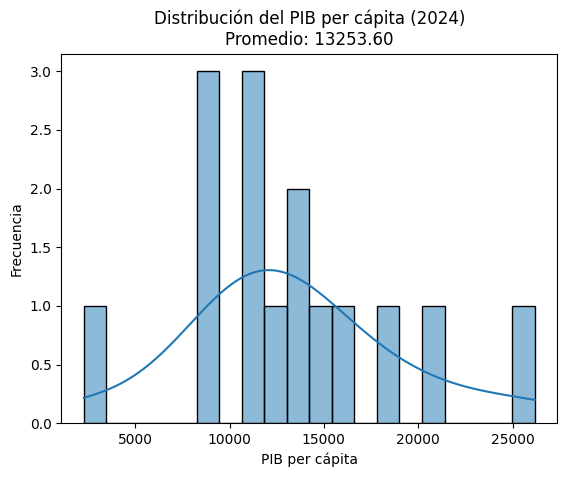

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt

# Crear figura
plt.figure()

# Histograma
sns.histplot(merged['city_gdp_capita'], bins=20, kde=True)

# Calcular promedio
mean_gdp = merged['city_gdp_capita'].mean()

# Título y etiquetas
plt.title(f'Distribución del PIB per cápita (2024)\nPromedio: {mean_gdp:.2f}')
plt.xlabel('PIB per cápita')
plt.ylabel('Frecuencia')

# Mostrar gráfico
plt.show()


<div class="alert alert-block alert-success"> 
<b>Comentario del Revisor #1</b> <a class="tocSkip"></a>

Generaste correctamente el histograma de PIB per cápita y añadiste etiquetas adecuadas. Esta visualización es útil para entender la distribución de la variable, detectar sesgos y evaluar la presencia de valores atípicos.

</div>

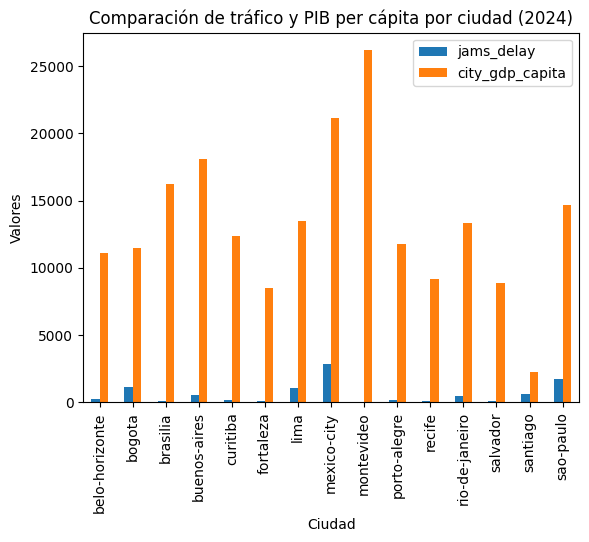

In [46]:
import matplotlib.pyplot as plt

# Crear gráfico de barras comparando ambas variables por ciudad
merged.plot(
    x='city',
    y=['jams_delay', 'city_gdp_capita'],
    kind='bar'
)

# Título y etiquetas
plt.title('Comparación de tráfico y PIB per cápita por ciudad (2024)')
plt.xlabel('Ciudad')
plt.ylabel('Valores')

# Ajustar etiquetas si hay muchas ciudades
plt.xticks(rotation=90)

plt.show()

<div class="alert alert-block alert-success"> 
<b>Comentario del Revisor #1</b> <a class="tocSkip"></a>

Generaste correctamente la comparación entre tráfico y economía utilizando con las variables _jams_delay_ y _city_gdp_capita_. Esta visualización permite explorar tendencias y posibles relaciones entre congestión y actividad económica, ofreciendo una perspectiva clara para el análisis exploratorio.

</div>

**Tip:** Antes del `plt.show()` agrega el código `plt.xticks(rotation=90)` para rotar las etiquetas del eje X en 90 grados.

### 🧠 **Reflexiona**
Excelente trabajo llegando a esta etapa del análisis. Antes de avanzar, revisa tus gráficos, tómate un momento para pensar:

* ¿Las ciudades con mayor PIB per cápita también presentan más congestión?

* ¿O sucede lo contrario, o no existe una relación clara?

Escribe tus comentarios:

<div class="alert alert-block alert-danger"> 
<b>Comentario del Revisor #1</b> <a class="tocSkip"></a>

No añadiste comentarios interpretativos sobre los patrones o relaciones observados en los gráficos o métricas. Es importante complementar cualquier visualización con una reflexión que explique qué tendencias se aprecian, si existen comportamientos atípicos, o qué posibles relaciones pueden inferirse entre las variables. Te sugiero detenerte a observar la forma general de la distribución, las diferencias entre grupos o la dirección de las tendencias, y expresar brevemente qué puedes concluir de ello. Este ejercicio fortalece tu análisis y demuestra comprensión del fenómeno estudiado.

</div>


---

## 🧩Paso 7: Exportar y documentar resultados

En esta etapa final consolidarás todo tu trabajo: guardarás el dataset limpio y crearás un resumen que documente los resultados del proyecto.

### 7.1 Guardar dataset final

**🎯Objetivo:**
Generar un CSV limpio, reproducible y con columnas relevantes para análisis posterior.

**Instrucciones**

- Exporta el DataFrame `merged` con el nombre: `ladb_mobility_economy_2024_clean.csv`
- Usa `index=False` para no incluir el índice.


In [49]:


merged.to_csv('ladb_mobility_economy_2024_clean.csv', index=False)

<div class="alert alert-block alert-success"> 
<b>Comentario del Revisor #1</b> <a class="tocSkip"></a>

Exportaste correctamente el DataFrame _merged_.

<div class="alert alert-block alert-warning"> 
<b>Comentario del Revisor #1</b> <a class="tocSkip"></a>

Te recomiendo verificar la exportación comprobando el tamaño del archivo con `os.path.getsize()`, una práctica adecuada para confirmar que el proceso se ejecutó correctamente y que el archivo no quedó vacío o corrupto. Mantener este tipo de verificaciones mejora la confiabilidad del pipeline de datos.

</div>

</div>

Para poder ver o descargar el archivo generado:   
En el menú lateral que esta a la izquierda, ve hasta la parte de abajo, a la sección de **Exportar dataset** para más información. 


---

## ✅ Entregables

1. **Notebook `.ipynb`** con todas las celdas (código + comentarios).
2. **CSV final**: `ladb_mobility_economy_2024_clean.csv`.
3. **Resumen ejecutivo breve** en Markdown (3–5 párrafos).



---

# 🧾 Resumen ejecutivo (plantilla)

> Completa este resumen al finalizar el análisis. Mantén 3–5 párrafos cortos, claros y accionables.

**Contexto & objetivo:**  
- Responde la pregunta central del análisis: ¿qué relación existe entre la movilidad urbana (congestión, tiempos de viaje) y la productividad económica (PIB per cápita)?
- Explica brevemente las variables clave utilizadas y su relevancia para la toma de decisiones.

**Cobertura de datos:**  
- Especifica los años analizados, número de ciudades y países incluidos.

**Metodología (alto nivel):**  
- Describe los procesos principales: limpieza de datos (formatos, estandarización de columnas).
- Explica la agregación por ciudad–año y el uso de una unión INNER para integrar tráfico y economía.
- Menciona las validaciones visuales empleadas (distribuciones, outliers, tendencias generales).

**Hallazgos iniciales:**  
- Resume los patrones más importantes entre índices de tráfico y PIB per cápita.
- Destaca anomalías u outliers que podrían requerir revisión adicional o un análisis más profundo.

**Recomendaciones**  
Aterriza los hallazgos en acciones: ciudades prioritarias, necesidad de validar fuentes, requerimiento de análisis adicionales, o propuestas de inversión.

- ¿Qué ciudad : Bogotá, Lima o Buenos Aires o alguna otra en particular, muestra la mayor correlación significativa entre altos niveles de congestión vehicular y bajos indicadores de productividad económica, sugiriendo ser una ciudad prioritaria para inversión en infraestructura de transporte?


Contexto & objetivo: 
El presente análisis tuvo como objetivo identificar la relación entre la movilidad urbana —medida a través de indicadores como jams_delay (minutos de congestión) y tiempos de viaje— y la productividad económica, representada por el PIB per cápita. Estas variables son clave para la toma de decisiones, ya que permiten evaluar cómo la congestión puede impactar la eficiencia económica de las ciudades.

Cobertura de datos:  
El análisis se centró en el año 2024, integrando información de múltiples ciudades a nivel internacional. Tras la limpieza y unificación de los datasets, se trabajó con un conjunto consolidado de ciudades presentes en ambas fuentes (movilidad y economía), asegurando consistencia en el análisis comparativo.

Metodología (alto nivel):  
Se realizó un proceso de limpieza de datos que incluyó la conversión de formatos (fechas y variables numéricas almacenadas como texto) y la estandarización de nombres de columnas. Posteriormente, se agregaron los datos a nivel ciudad–año y se utilizó una unión tipo INNER para integrar ambos datasets. Finalmente, se emplearon visualizaciones (boxplots, histogramas y gráficos de barras) para validar distribuciones, detectar valores atípicos y observar tendencias generales.

Hallazgos iniciales:  
Los resultados muestran que no existe una relación lineal clara entre el PIB per cápita y los niveles de congestión. Sin embargo, se identifican casos donde ciudades con niveles relativamente bajos de PIB presentan alta congestión, lo que sugiere limitaciones en infraestructura o planeación urbana. Asimismo, se detectaron valores atípicos tanto en congestión como en indicadores económicos que podrían influir en el análisis general.

Recomendaciones:  
Se recomienda priorizar el análisis en ciudades donde coexisten altos niveles de congestión y bajos indicadores económicos, ya que representan áreas críticas para inversión en infraestructura de transporte. Entre las ciudades evaluadas, Bogota destaca como un caso donde se observa esta combinación de manera más consistente, lo que sugiere que podría ser una candidata prioritaria para intervenciones. Adicionalmente, se recomienda complementar el análisis con métricas de correlación y estudios longitudinales para validar estos hallazgos y fortalecer la toma de decisiones.